In [ ]:
#.Importing
from astroquery.vizier import Vizier
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle,SkyCoord
from astropy import units as u
from astropy.stats import sigma_clipped_stats, mad_std, biweight_location
from scipy.stats import binned_statistic

import numpy as np
from photutils.segmentation import detect_threshold
from photutils.detection import find_peaks, IRAFStarFinder
from photutils.aperture import CircularAperture
from sklearn.neighbors import NearestNeighbors
from itertools import product, repeat
from scipy.optimize import curve_fit

from mylib.phot_functions import windowed_centroid
from convenience_functions5 import show_image
from matplotlib import pyplot as plt


: 

In [2]:
def wcs_setup(header, instrument='SAMI'):

    if "WCSASTRM" in header: del header["WCSASTRM"]
    if "RADECEQ" in header: del header["RADECEQ"]
    if "WAT0_001" in header: del header["WAT0_001"]
    if "WAT1_001" in header: del header["WAT1_*"]
    if "WAT2_001" in header: del header["WAT2_*"]
    if "PC1_1" in header: del header["PC1_*"]
    if "PC2_1" in header: del header["PC2_*"]

    header.insert("RADECSYS",("RADESYSa", "FK5", "Default coordinate system"))
    header["EQUINOX"] = (2000., "Equinox of WCS")
    header["CTYPE1"] = ("RA---TAN", "Coordinate type")
    header["CTYPE2"] = ("DEC--TAN", "Coordinate type")
    header.insert("CRVAL1",("CUNIT1", "deg", "Coordinate unit"))
    header.insert("CRVAL1",("CUNIT2", "deg", "Coordinate unit"))
    
    if instrument == "SAMI":
        ccdsum = np.array([ float(bin) for bin in hdr1['CCDSUM'].split() ])
        point_ra = Angle(header['TELRA'], unit = u.hourangle).value*15
        point_dec = Angle(header['TELDEC'], unit = u.degree).value
        crpix1 = 2048/ccdsum[0]
        crpix2 = 2056/ccdsum[1]
        CDval = 1.25e-05*ccdsum
        camrot = header['DECPANGL']+header['ROTOFFS']
    elif instrument == "Goodman":
        ccdsum = np.array([ float(bin) for bin in hdr1['CCDSUM'].split() ])
        point_ra = Angle(header['RA'], unit = u.hourangle).value*15
        point_dec = Angle(header['DEC'], unit = u.degree).value
        crpix1 = 1548/ccdsum[0]
        crpix2 = 1548/ccdsum[1]
        CDval = 4.012792e-05*ccdsum
        camrot = header['POSANGLE']

    header["CDELT1"] = CDval[0]
    header["CDELT2"] = CDval[1]
    header["CRVAL1"] = point_ra
    header["CRVAL2"] = point_dec
    header["CRPIX1"] = crpix1
    header["CRPIX2"] = crpix2

    cost = np.cos(camrot * np.pi/180)
    sent = np.sin(camrot * np.pi/180)
    header["CD1_1"] = CDval[0] * cost
    header["CD1_2"] = abs(CDval[1]) * np.sign(CDval[0]) * sent
    header["CD2_1"] = -abs(CDval[0]) * np.sign(CDval[1]) * sent
    header["CD2_2"] = CDval[1] * cost

    return header

def tangent_shift(header, new_crpix, is_shift=False):
    ncrpix1, ncrpix2 = new_crpix

    if is_shift: 
        dx = ncrpix1
        dy = ncrpix2
        ncrpix1 += header["CRPIX1"]
        ncrpix2 += header["CRPIX2"]
    else: 
        dx = ncrpix1 - header["CRPIX1"]
        dy = ncrpix2 - header["CRPIX2"]

    CD_matrix = np.array([  [header["CD1_1"], header["CD1_2"]], 
                            [header["CD2_1"], header["CD2_2"]]  ])
    d_alpha, d_delta = CD_matrix @ np.array([dx,dy])
    d_alpha /= np.cos(header["CRVAL2"]*np.pi/180)

    header["CRPIX1"] = ncrpix1
    header["CRPIX2"] = ncrpix2
    header["CRVAL1"] += d_alpha
    header["CRVAL2"] += d_delta

    return header

In [3]:
#.Reading data
imgname = 'SO2018B-009.155.fits'
#imgname = 'SO2018B-009.175.fits'
hdu1 = fits.open(imgname)

#.Getting image data (img) and header data (hdr) from the first fits extension
img1 = hdu1[0].data 
hdr1 = hdu1[0].header
imsz = img1.shape
hdu1.close()

#..reading important header keywords
fwhm = hdr1['FWHM']
exptime=hdr1['EXPTIME']
ra=Angle(hdr1['TELRA'], unit=u.hourangle)
dec=Angle(hdr1['TELDEC'], unit=u.degree)

hdr1 = wcs_setup(hdr1)
wcs = WCS(hdr1)
wcs

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 83.929375  -69.25396  
CRPIX : 1024.0  1028.0  
CD1_1 CD1_2  : 2.5e-05  0.0  
CD2_1 CD2_2  : -0.0  2.5e-05  
NAXIS : 2048  2056

1029


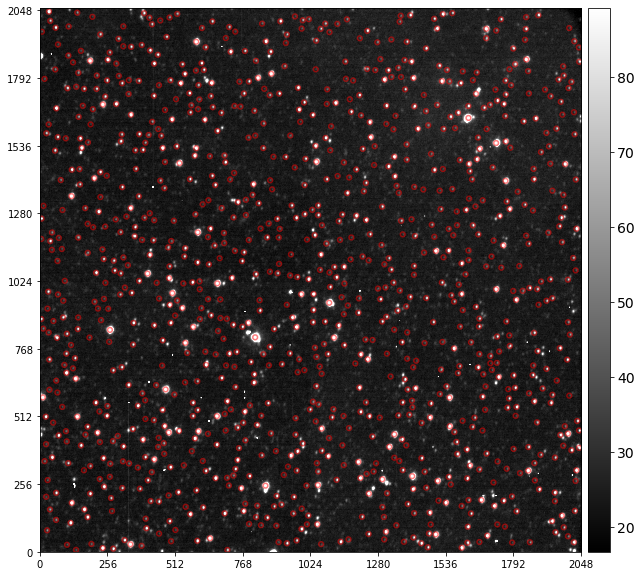

In [4]:
#.Using sigma-clipping to model the background
back_mean, back_median, back_std = sigma_clipped_stats( img1, 
    cenfunc='median', stdfunc=mad_std,
    sigma_lower=3, sigma_upper=2, maxiters=10 )

#.Detecting sources using IRAFStarfinder method
starfinder = IRAFStarFinder(3*back_std, fwhm, sky=back_median,
                            exclude_border=True, brightest=1e5)
tab = starfinder.find_stars(img1)
print(len(tab))

#.Making detections table to compare with the catalog
tab['mag'] += (25 + 2.5*np.log10(exptime))
data_pix = np.transpose((tab['xcentroid'], tab['ycentroid'], tab['mag']))

#..plotting detections
fig, ax = plt.subplots(1,1,figsize=(10,10))
show_image(img1,fig=fig,ax=ax,cmap='gray')
data_aper = CircularAperture(data_pix[:,0:2], r=9.)
data_aper.plot(color='red', lw=1.5, alpha=0.5, axes=ax);

In [4]:
#.Selecting the astrometric catalog
#catalog, magcol = 'I/297', 'Rmag' # values for the NOMAD catalog
catalog, magcol = 'I/350', 'Gmag' # values for the GAIA catalog

#.Querying Vizier for the catalog
Vizier.ROW_LIMIT = -1
query = Vizier.query_region(SkyCoord(ra=ra, dec=dec, frame='icrs'),
                            width="4.1 arcmin", catalog=catalog)

cat=query[0]

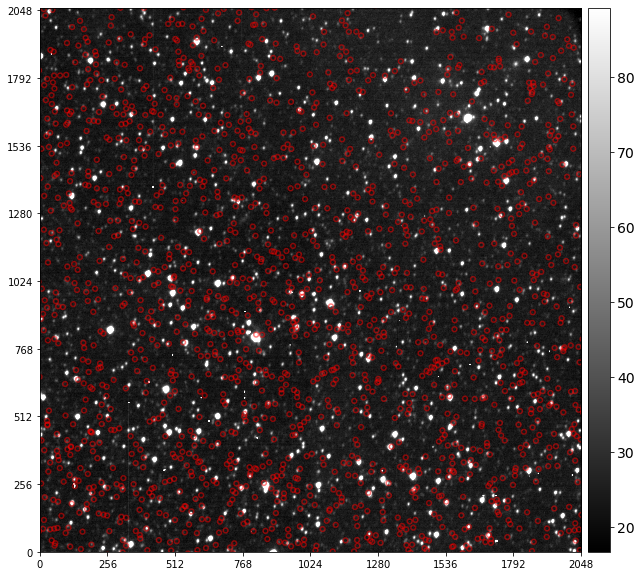

In [10]:
#..getting celestial positions of the catalog stars
cat_pos = SkyCoord( cat['RAJ2000'].data*u.degree, 
                    cat['DEJ2000'].data*u.degree,
                    frame='icrs')

#..transforming positions to pixel values using the image WCS
cat_pix = np.transpose(wcs.world_to_pixel(cat_pos))

#..plotting image
fig, ax = plt.subplots(1,1,figsize=(10,10))
show_image(img1,fig=fig,ax=ax,cmap='gray')
#..overplotting catalog objects
data_aper = CircularAperture(cat_pix[:,0:2], r=9.)
data_aper.plot(color='red', lw=1.5, alpha=0.5, axes=ax);

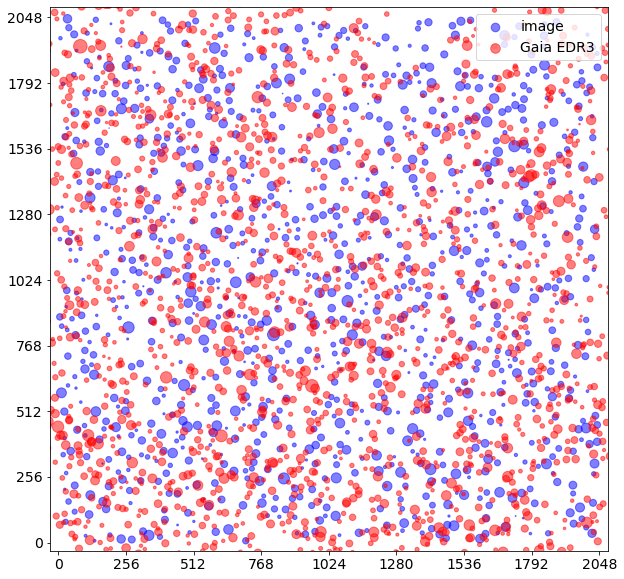

In [6]:
#.selecting only catalog data with magnitude info
mask = (cat[magcol].mask == False)
#..getting celestial positions of the catalog stars
cat_pos = SkyCoord( cat['RAJ2000'][mask].data*u.degree, 
                    cat['DEJ2000'][mask].data*u.degree,
                    frame='icrs')

#..transforming positions to pixel values using the image WCS
cat_pix = np.transpose(wcs.world_to_pixel(cat_pos))

#..adding a magnitude column to the catalog stars
mag = np.array(cat[magcol][mask].data).reshape(len(cat_pix),1)
cat_pix = np.hstack((cat_pix, mag))

fig, ax1 = plt.subplots(1,1, figsize=(10,10))
ax1.scatter(data_pix[:,0], data_pix[:,1], marker='o', color='blue',
            s=20*(np.max(data_pix[:,2])-data_pix[:,2]), alpha=0.5,
            label='image')
ax1.scatter(cat_pix[:,0], cat_pix[:,1], marker='o', color='red', 
            s=20*(mag.max()-mag), alpha=0.5, label='Gaia EDR3');
ax1.set_xlim(-32, imsz[1]+32)
ax1.set_ylim(-32, imsz[0]+32)
ax1.xaxis.set_major_locator(plt.MultipleLocator(256))
ax1.yaxis.set_major_locator(plt.MultipleLocator(256))
ax1.legend()

[160] [-200]
[ 151.0034717  -200.07130221]


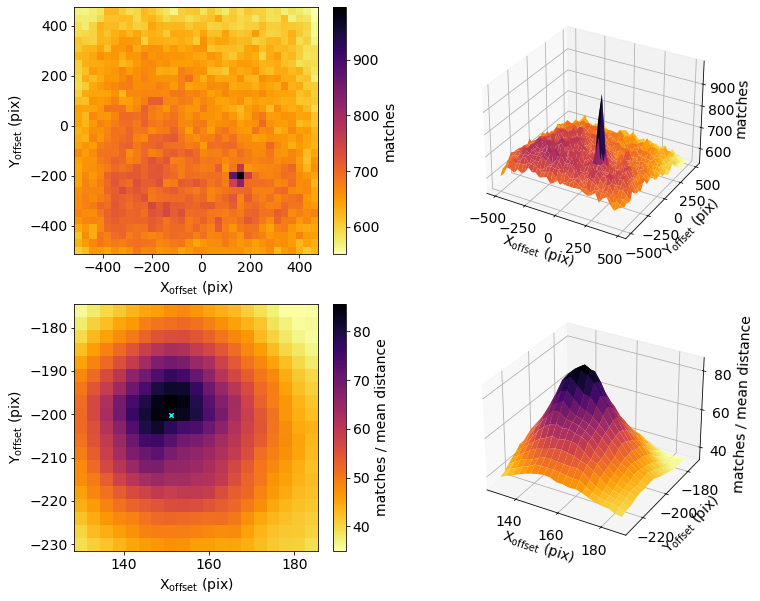

In [7]:
def cat_translation(dat,cat, match_radius=20, max_shift=500):

    #.gathering data information
    ndat = dat.shape[0]
    dat_min = np.min(dat,axis=0)
    dat_max = np.max(dat,axis=0)
    dat_size = np.round((dat_max[0:2]-dat_min[0:2])/256)*256
    #.gathering catalog information
    ncat = cat.shape[0]
    cat_min = np.min(cat,axis=0)
    cat_max = np.max(cat,axis=0)
    cat_size = cat_max[0:2]-cat_min[0:2]
  
    #.checking for density differences between tables
    dat_den = ndat/np.product(dat_size)
    cat_den = ncat/np.product(cat_size)
    den_ratio = dat_den/cat_den
    #..removing faintest stars from the densest table
    if den_ratio > 1.5: 
        sort = np.argsort(dat[:,2])
        ndat = int(round(ndat/den_ratio))
        dat = dat[sort[:ndat],:]
    elif den_ratio < 0.75:
        sort = np.argsort(cat[:,2])
        ncat = int(round(ncat*den_ratio))
        cat = cat[sort[:ncat],:]

    #.building translation grid
    grid_bin = match_radius
    tgrid_y = np.arange(-max_shift, max_shift, grid_bin)
    tgrid_x = np.arange(-max_shift, max_shift, grid_bin)
    grid_x, grid_y = np.meshgrid(tgrid_x, tgrid_y)
    
    #.setting up Neighbors structure
    nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto')
    nbrs.fit(cat_pix[:,0:2])

    #..finding the matches at each grid position
    grid_shape = (len(tgrid_x), len(tgrid_y))
    nmatch = np.zeros(grid_shape)
    dists = np.full(grid_shape, match_radius)
    for i in range(len(tgrid_x)):
        for j in range(len(tgrid_y)):
            xoff, yoff = tgrid_x[i], tgrid_y[j]
            dist, _ = nbrs.kneighbors(dat[:,0:2]+[xoff,yoff])
            dist = dist[dist < match_radius]
            nmatch[j,i] = len(dist)
            if nmatch[j,i] > 0: dists[j,i] = np.median(dist)

    #..obtaining optimal offsets in X and Y
    imax = np.where(nmatch == nmatch.max())
    xoffset, yoffset = grid_x[imax], grid_y[imax]
    print(xoffset,yoffset)

    #-----------------------------------------------------------------------------
    #.Plotting colormesh of the number of matches for each offset
    fig = plt.figure(figsize=(12,10))
    ax1 = fig.add_subplot(2,2,1)
    cm = ax1.pcolormesh(grid_x-grid_bin/2, grid_y-grid_bin/2, nmatch[:-1,:-1],
                        cmap='inferno_r')
    plt.colorbar(cm, label='matches', ax=ax1,)
    ax1.set_xlabel(r'X$_\mathrm{offset}$ (pix)')
    ax1.set_ylabel(r'Y$_\mathrm{offset}$ (pix)')

    #.Plotting surface of the number of matches for each offset
    ax2 = fig.add_subplot(2,2,2, projection='3d')
    surf = ax2.plot_surface(grid_x, grid_y, nmatch, cmap='inferno_r',
                       linewidth=0, antialiased=True)
    ax2.set_xlabel(r'X$_\mathrm{offset}$ (pix)')
    ax2.set_ylabel(r'Y$_\mathrm{offset}$ (pix)')
    ax2.set_zlabel(r'matches')

    #-----------------------------------------------------------------------------
    #.Refining the grid
    rgrid_bin = match_radius/10.
    tgrid_y = np.arange(yoffset-match_radius, yoffset+match_radius, rgrid_bin)
    tgrid_x = np.arange(xoffset-match_radius, xoffset+match_radius, rgrid_bin)
    rgrid_x, rgrid_y = np.meshgrid(tgrid_x, tgrid_y)

    #..finding the matches at each grid position
    grid_shape = (len(tgrid_x), len(tgrid_y))
    rmatch = np.zeros(grid_shape)
    rdist = np.zeros(grid_shape)
    for i in range(len(tgrid_x)):
        for j in range(len(tgrid_y)):
            xoff, yoff = tgrid_x[i], tgrid_y[j]
            dist, _ = nbrs.kneighbors(dat[:,0:2]+[xoff,yoff])
            dist = dist[dist < match_radius]
            rmatch[j,i] = len(dist)
            rdist[j,i] = np.median(dist)

    #..obtaining final offsets in X and Y
    cdata = rmatch/rdist
    imax = np.where(cdata == cdata.max())
    xoffset, yoffset = rgrid_x[imax], rgrid_y[imax]
    center_data = windowed_centroid(cdata, x_grid=rgrid_x, y_grid=rgrid_y,
                                    initial_center=[xoffset,yoffset])
    xoffset, yoffset = center_data[-1,0:2]


    #.Plotting colormesh zoom
    ax1 = fig.add_subplot(2,2,3)
    cm = ax1.pcolormesh(rgrid_x-rgrid_bin/2, rgrid_y-rgrid_bin/2, 
                        rmatch[:-1,:-1]/rdist[:-1,:-1], cmap='inferno_r')
    ax1.scatter(xoffset, yoffset, marker='x', color='cyan', s=20)
    plt.colorbar(cm, label='matches / mean distance', ax=ax1,)
    ax1.set_xlabel(r'X$_\mathrm{offset}$ (pix)')
    ax1.set_ylabel(r'Y$_\mathrm{offset}$ (pix)')

    #.Plotting surface zoom
    ax2 = fig.add_subplot(2,2,4, projection='3d')
    surf = ax2.plot_surface(rgrid_x, rgrid_y, rmatch/rdist, cmap='inferno_r',
                       linewidth=0, antialiased=True)
    ax2.set_xlabel(r'X$_\mathrm{offset}$ (pix)')
    ax2.set_ylabel(r'Y$_\mathrm{offset}$ (pix)')
    ax2.set_zlabel(r'matches / mean distance')

    return xoffset[0], yoffset[0]

#.finding the optimal translation between the catalog and image stars
xoff, yoff = cat_translation(data_pix, cat_pix, match_radius=30)
tra1 = np.array([xoff,yoff])
print(tra1)

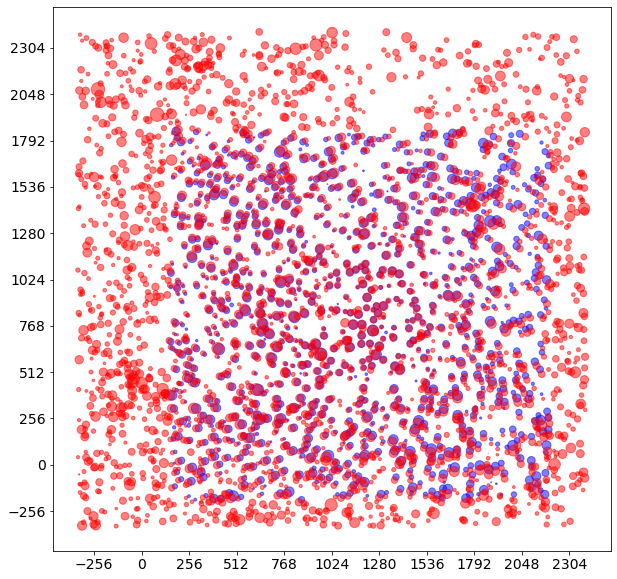

In [8]:
#..comparing the positions of the image+offsets and catalogue stars
fig, ax = plt.subplots(1,1,figsize=(10,10))
ax.scatter(data_pix[:,0]+xoff, data_pix[:,1]+yoff, marker='o', color='blue',
            s=20*(np.max(data_pix[:,2])-data_pix[:,2]), alpha=0.5)
ax.scatter(cat_pix[:,0], cat_pix[:,1], marker='o', color='red', 
            s=20*(mag.max()-mag), alpha=0.5);
# ax.set_xlim(0, imsz[1])
# ax.set_ylim(0, imsz[0])
ax.xaxis.set_major_locator(plt.MultipleLocator(256))
ax.yaxis.set_major_locator(plt.MultipleLocator(256))


In [9]:
#.matching the catalog with the translated image postions
nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(cat_pix[:,0:2])
dist, indx = nbrs.kneighbors(data_pix[:,0:2]+np.array([xoff,yoff]).T)
#..selecting only matches with distance inferior to the selected threshold
match_threshold=30
mask = (dist < match_threshold)
dist, indx = dist[mask], indx[mask]

#..saving the matched stars in new tables
match_data = data_pix[mask.flatten(),0:2] + np.array([xoff,yoff]).T
match_cat = cat_pix[indx.flatten(),0:2]

In [10]:
def rigid_transform_3D(A, B, scale=True):
    assert len(A) == len(B)

    N = A.shape[0];  # total points

    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)

    # center the points
    AA = A - np.tile(centroid_A, (N, 1))
    BB = B - np.tile(centroid_B, (N, 1))

    # @ is matrix multiplication for array
    if scale:
        H = np.transpose(BB) @ AA / N
    else:
        H = np.transpose(BB) @ AA

    U, S, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T

    # special reflection case
    if np.linalg.det(R) < 0:
        print("Reflection detected")
        Vt[2, :] *= -1
        R = Vt.T @ U.T

    if scale:
        varA = np.var(A, axis=0).sum()
        c = 1 / (1 / varA * np.sum(S))  # scale factor
        t = -R @ (centroid_B.T * c) + centroid_A.T
    else:
        c = 1
        t = -R @ centroid_B.T + centroid_A.T

    return c, R, t

#.Using Kabsh algoritm to find the optimal scaling and rotation of the data
sca, rot, tra2 = rigid_transform_3D(match_cat[:,0:2],match_data[:,0:2], scale=False)
print("scale:",sca,"\n","translation:",tra2,"\n","rotation:\n",rot)

#..calculating the residuals of the transformation:
cor_dat = sca*(rot @ match_data.T).T + tra2
rms = np.sum((cor_dat-match_cat)**2, axis=0)**0.5/len(cor_dat)
print("transormation RMS (pixels):",rms)

scale: 1 
 translation: [-7.55617647  9.65632944] 
 rotation:
 [[ 0.99994964  0.01003546]
 [-0.01003546  0.99994964]]
transormation RMS (pixels): [0.24461993 0.25732044]


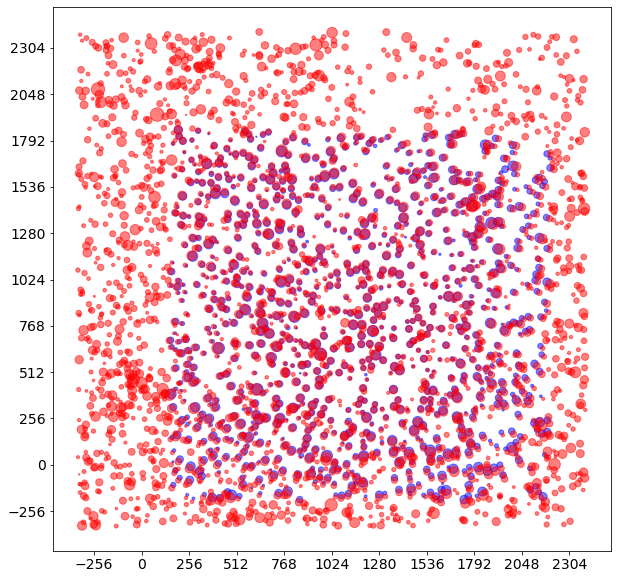

In [11]:
#..plotting data and catalogue
fig, ax = plt.subplots(1,1,figsize=(10,10))
m = mask.flatten()
ax.scatter(cor_dat[:,0], cor_dat[:,1], marker='o', color='blue',
            s=20*(np.max(data_pix[m,2])-data_pix[m,2]), alpha=0.5)
ax.scatter(cat_pix[:,0], cat_pix[:,1], marker='o', color='red', 
            s=20*(mag.max()-mag), alpha=0.5);
ax.xaxis.set_major_locator(plt.MultipleLocator(256))
ax.yaxis.set_major_locator(plt.MultipleLocator(256))


In [12]:
#.Calculating WCS coefficients from the transformation
CD_mat = np.array([ [hdr1['CD1_1'], hdr1['CD1_2']],
                    [hdr1['CD2_1'], hdr1['CD2_2']] ])
CD_upd = sca*(CD_mat @ rot)

CRp = np.array([hdr1['CRPIX1'], hdr1['CRPIX2']])
inv_rot = np.linalg.inv(rot)
CRp_upd = inv_rot @ (CRp - sca*(rot @ tra1) - tra2) / sca

#.Updating image header with new WCS values
hdr1['CD1_1'] = CD_upd[0,0]
hdr1['CD1_2'] = CD_upd[0,1]
hdr1['CD2_1'] = CD_upd[1,0]
hdr1['CD2_2'] = CD_upd[1,1]
hdr1['CRPIX1'] = CRp_upd[0]
hdr1['CRPIX2'] = CRp_upd[1]

with fits.open(imgname, mode='update') as hdu:
    hdu[0].header = hdr1

wcs = WCS(hdr1)
wcs


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 83.929375  -69.25396  
CRPIX : 870.2812113248199  1228.715834007407  
CD1_1 CD1_2  : 2.49987410874087e-05  2.50886517572596e-07  
CD2_1 CD2_2  : -2.508865175726e-07  2.49987410874087e-05  
NAXIS : 2048  2056

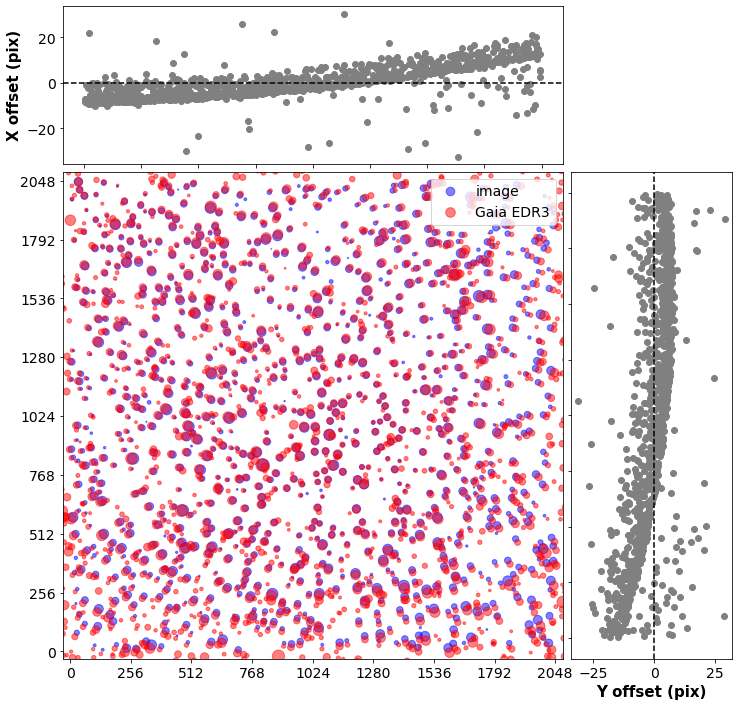

In [13]:
#..transforming positions to pixel values using the image WCS
mask = (cat[magcol].mask == False)
cat_pix = np.transpose(wcs.world_to_pixel(cat_pos))

#..adding a magnitude column to the catalog stars
mag = np.array(cat[magcol][mask].data).reshape(len(cat_pix),1)
cat_pix = np.hstack((cat_pix, mag))

#.matching the catalog with the translated image postions
nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(cat_pix[:,0:2])
dist, indx = nbrs.kneighbors(data_pix[:,0:2])
#..selecting only matches with distance inferior to the selected threshold
match_threshold=35
mask = (dist < match_threshold)
dist, indx = dist[mask], indx[mask]

#..saving the matched stars in new tables
match_data = data_pix[mask.flatten(),0:2]
match_cat = cat_pix[indx.flatten(),0:2]
pos_diff = match_cat - match_data

fig = plt.figure(figsize=(12,12))
ax1 = fig.add_subplot(4,4,(5,15))
ax2 = fig.add_subplot(4,4,(1,3))
ax3 = fig.add_subplot(4,4,(8,16))

plt.subplots_adjust(wspace=0.05, hspace=0.05)

#..plotting stars from image and from the catalogue
ax1.scatter(data_pix[:,0], data_pix[:,1], marker='o', color='blue',
            s=20*(np.max(data_pix[:,2])-data_pix[:,2]), alpha=0.5,
            label='image')
ax1.scatter(cat_pix[:,0], cat_pix[:,1], marker='o', color='red', 
            s=20*(mag.max()-mag), alpha=0.5, label='Gaia EDR3');
ax1.set_xlim(-32, imsz[1]+32)
ax1.set_ylim(-32, imsz[0]+32)
ax1.xaxis.set_major_locator(plt.MultipleLocator(256))
ax1.yaxis.set_major_locator(plt.MultipleLocator(256))
ax1.legend()

sc = ax2.scatter(match_data[:,0], pos_diff[:,0], c='gray')#, c=np.sum(pos_diff**2,axis=1)**0.5)
ax2.xaxis.set_major_locator(plt.MultipleLocator(256))
ax2.set_xticklabels([])
ax2.set_ylabel('X offset (pix)',fontsize=15, fontweight='bold')
ax2.axhline(0,ls='--',c='black')

ax3.scatter(pos_diff[:,1], match_data[:,1], c='gray')#, c=np.sum(pos_diff**2,axis=1)**0.5)
ax3.yaxis.set_major_locator(plt.MultipleLocator(256))
ax3.set_yticklabels([])
ax3.set_xlabel('Y offset (pix)',fontsize=15, fontweight='bold')
ax3.axvline(0,ls='--',c='black')

In [14]:
def sip_polynomial( data, *AB_coefs):

    x_data = data[:,0]
    y_data = data[:,1]
    ndata = len(x_data)

    #.defininng SIP polynomials terms
    x_exponents = np.array(list(repeat(xy_orders[0,:],ndata))).T
    y_exponents = np.array(list(repeat(xy_orders[1,:],ndata))).T
    x_coefs = np.array(list(repeat(AB_coefs,ndata))).T

    #.evaluating SIP polynomial
    f = np.sum(x_coefs * x_data**x_exponents * y_data**y_exponents, axis=0)

    return f

def SIP_orders(order, min_order=2, remove_order=None):
    
    #.obtaining SIP polyomial terms up to the max order required
    xy_orders = np.array(list(product(range(order+1),repeat=2))).T
    total_order = np.sum(xy_orders,axis=0)
    valid_order = (total_order >= min_order) & (total_order <= order)
    xy_orders = xy_orders[:,valid_order]
    
    #removing particular orders 
    if (remove_order is not None): 
        rmvord = np.array(remove_order).reshape(int(np.size(remove_order)/2),2)
        for order in rmvord:
            left_orders = (xy_orders[0,:] != order[0]) | (xy_orders[1,:] != order[1])
            xy_orders = xy_orders[:,left_orders]

    return np.c_[[0,0], xy_orders]

from scipy.stats import binned_statistic
from astropy.stats import mad_std, biweight_location, biweight_scale

def histo_sclip(x, data, bins=32, nsigma=6, nclip=1, **kwargs):
    ndat, ndim = np.shape(data)
    oidx = np.arange(ndat)
    outx = np.full(ndat, 1, dtype=bool)
    outy = np.full(ndat, 1, dtype=bool)
    out = outx & outy

    for n in np.arange(nclip):
        idx = oidx[out]
        x_med, x_bin, x_idx = binned_statistic(x[out,0], data[out,0], statistic=biweight_location, bins=bins, **kwargs) 
        x_std, _, _ = binned_statistic(x[out,0], data[out,0], statistic=mad_std, bins=bins, **kwargs)
        y_med, y_bin, y_idx = binned_statistic(x[out,1], data[out,1], statistic=biweight_location, bins=bins, **kwargs)
        y_std, _, _ = binned_statistic(x[out,1], data[out,1], statistic=mad_std, bins=bins, **kwargs)
        for i in np.arange(0,int(bins)):
            wx = idx[x_idx == i+1]
            wy = idx[y_idx == i+1]
            outx[wx] *= (abs(x_res[wx]-x_med[i]) <= nsigma*x_std[i])
            outy[wy] *= (abs(y_res[wy]-y_med[i]) <= nsigma*y_std[i])
            out = outx & outy

    return outx, outy

    # fig, [ax2,ax3] = plt.subplots(2,1,figsize=(10,8))

    # ax2.scatter(match_data[:,0], x_res, c=np.sqrt(x_res**2 + y_res**2))
    # ax2.xaxis.set_major_locator(plt.MultipleLocator(256))
    # ax2.set_ylabel('x residuals',fontsize=15, fontweight='bold')
    # ax2.plot(x_bin[:-1]+binsz/2, x_med, ls='--', c='black')
    # ax2.plot(x_bin[:-1]+binsz/2, x_med+nstd*x_std, ls=':', c='black')
    # ax2.plot(x_bin[:-1]+binsz/2, x_med-nstd*x_std, ls=':', c='black')
    # ax2.scatter(match_data[~outx,0], x_res[~outx], color='red', marker='x')


    # ax3.scatter(match_data[:,1], y_res,c=np.sqrt(x_res**2 + y_res**2))
    # ax3.xaxis.set_major_locator(plt.MultipleLocator(256))
    # ax3.set_ylabel('y residuals',fontsize=15, fontweight='bold')
    # ax3.plot(y_bin[:-1]+binsz/2, y_med, ls='--', c='black')
    # ax3.plot(y_bin[:-1]+binsz/2, y_med+nstd*y_std, ls=':', c='black')
    # ax3.plot(y_bin[:-1]+binsz/2, y_med-nstd*y_std, ls=':', c='black')
    # ax3.scatter(match_data[~outy,1], y_res[~outy], color='red', marker='x')

    # fig, ax1 = plt.subplots(1,1,figsize=(10,10))
    # print(np.sum(out))
    # ax1.quiver(match_data[out,0],match_data[out,1],residuals[out,0],residuals[out,1],
    #             angles='xy', scale_units='xy', scale=1/3)
    # ax1.scatter(x_cen,y_cen,marker='x',s=20,c='red')
    # ax1.xaxis.set_major_locator(plt.MultipleLocator(256))
    # ax1.yaxis.set_major_locator(plt.MultipleLocator(256))



In [15]:
#.testing order removal

# all orders
print('all orders')
print( SIP_orders(4) )

# remove order (3,1)
print('remove order (3,1)')
print( SIP_orders( 4, remove_order=(3,1) ) )

# remove orders (1,1) and (3,1)
print('remove orders (1,1) and (3,1)')
print( SIP_orders( 4, remove_order=[(1,1),(3,1)] ) )

all orders
[[0 0 0 0 1 1 1 2 2 2 3 3 4]
 [0 2 3 4 1 2 3 0 1 2 0 1 0]]
remove order (3,1)
[[0 0 0 0 1 1 1 2 2 2 3 4]
 [0 2 3 4 1 2 3 0 1 2 0 0]]
remove orders (1,1) and (3,1)
[[0 0 0 0 1 1 2 2 2 3 4]
 [0 2 3 4 2 3 0 1 2 0 0]]


In [16]:
#..setting tangent point to the upper-left corner of the image
#  (polynomial convergence puts the 'optimal' center near this position)
hdr1 = tangent_shift(hdr1,[0,2056])

#..preparing SIP polynomials orders
x_pol, y_pol = 4, 3
removed_ord = None
x_cen, y_cen = hdr1['CRPIX1'], hdr1['CRPIX2']

nit=4
for i in np.arange(1,nit+1):

    #..preparing input x-data and y-data for fitting
    residuals = match_cat - match_data
    input = match_data - np.array([x_cen, y_cen]).T

    xy_orders = SIP_orders(x_pol, remove_order=removed_ord)
    initial = np.full(len(xy_orders[0,:]),1e-6)
    x_coefs, x_cov = curve_fit( sip_polynomial, input, residuals[:,0], p0=initial )
    x_error = np.sqrt(np.diag(x_cov))
    print('x coefficients')
    temp = np.array([ xy_orders[0,:],  xy_orders[1,:], x_coefs, abs(x_error/x_coefs)]).T
    for c1,c2,c3,c4 in temp: print("%1i %1i | %8e | %3f" % (c1, c2, c3, c4))

    xy_orders = SIP_orders(y_pol, remove_order=removed_ord)
    initial = np.full(len(xy_orders[0,:]),1e-6)
    y_coefs, y_cov = curve_fit( sip_polynomial, input, residuals[:,1], p0=initial )
    y_error = np.sqrt(np.diag(y_cov))
    print('y coefficients')
    temp = np.array([ xy_orders[0,:],  xy_orders[1,:], y_coefs, abs(y_error/y_coefs)]).T
    for c1,c2,c3,c4 in temp: print("%1i %1i | %8e | %3f" % (c1, c2, c3, c4))
    
    xy_orders = SIP_orders(x_pol, remove_order=removed_ord)
    x_cor2 = sip_polynomial( input, *x_coefs )
    xy_orders = SIP_orders(y_pol, remove_order=removed_ord)
    y_cor2 = sip_polynomial( input, *y_coefs )

    x_res = residuals[:,0] - x_cor2
    y_res = residuals[:,1] - y_cor2

    rmse_x = np.sqrt(np.sum(x_res**2)/len(x_res))
    rmse_y = np.sqrt(np.sum(y_res**2)/len(y_res))
    
    # sigclip = (abs(x_res) <= 3*rmse_x) & (abs(y_res) <= 3*rmse_y)
    # print(np.sum(sigclip))
    sigx, sigy = histo_sclip(match_data, np.array([x_res,y_res]).T, bins=16, range=(0,2048))
    sigclip = sigx & sigy
    if i != nit: 
        match_data = match_data[sigclip,:]
        match_cat = match_cat[sigclip,:]
        residuals = residuals[sigclip,:]

    print('RMSE_x',rmse_x)
    print('RMSE_y',rmse_y)
    print('RMSE',np.sqrt(np.sum(x_res**2 + y_res**2)/len(x_res)))


x coefficients
0 0 | -1.117144e+00 | 0.598998
0 2 | -1.322436e-05 | 0.314214
0 3 | -1.035508e-08 | 0.438860
0 4 | -2.260367e-12 | 0.585071
1 1 | 9.054900e-06 | 0.650061
1 2 | 6.970286e-09 | 0.625407
1 3 | 7.654096e-13 | 1.714886
2 0 | 7.350492e-06 | 0.593721
2 1 | -4.650395e-09 | 0.885216
2 2 | -3.432094e-12 | 0.419798
3 0 | -1.779387e-09 | 2.667196
3 1 | -5.311749e-13 | 2.344515
4 0 | -6.922915e-14 | 19.844924
y coefficients
0 0 | 6.607936e+00 | 0.083485
0 2 | -4.385208e-06 | 0.319222
0 3 | 2.624648e-10 | 2.680872
1 1 | -5.502338e-07 | 3.804242
1 2 | 6.040366e-10 | 1.396872
2 0 | -1.861205e-08 | 77.731176
2 1 | -1.936432e-10 | 4.094308
3 0 | -1.313602e-09 | 0.546630
RMSE_x 4.61336696511235
RMSE_y 5.526585043144163
RMSE 7.199048339460897
x coefficients
0 0 | -6.626961e-01 | 0.276934
0 2 | -1.500856e-05 | 0.078018
0 3 | -1.058876e-08 | 0.121740
0 4 | -2.025676e-12 | 0.186204
1 1 | 1.079423e-05 | 0.155608
1 2 | 1.166786e-08 | 0.108169
1 3 | 2.731862e-12 | 0.139800
2 0 | 9.299393e-06 | 0.

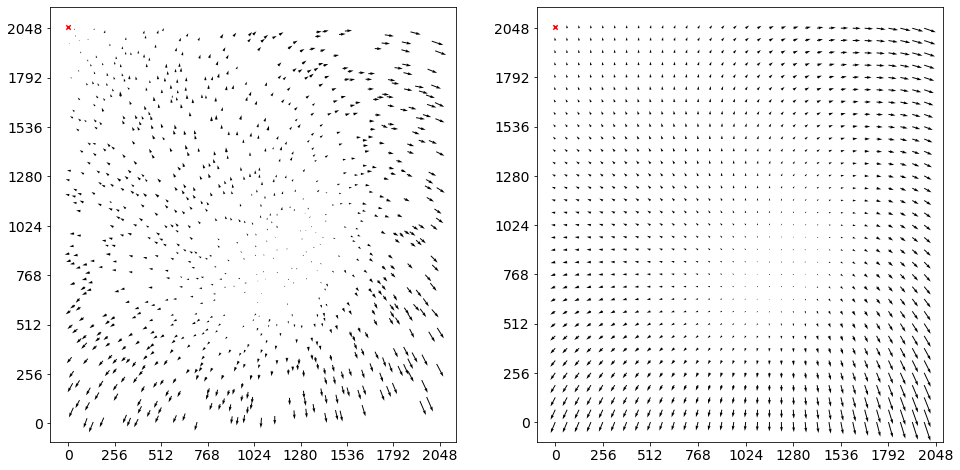

In [17]:
fig, [ax1,ax2] = plt.subplots(1,2, figsize=(16,8))
ax1.quiver(match_data[:,0],match_data[:,1],residuals[:,0],residuals[:,1],
            angles='xy', scale_units='xy', scale=1/3)
ax1.scatter(x_cen,y_cen,marker='x',s=20,c='red')
ax1.xaxis.set_major_locator(plt.MultipleLocator(256))
ax1.yaxis.set_major_locator(plt.MultipleLocator(256))

x_ori, y_ori = np.meshgrid(np.arange(0,2048,64), np.arange(0,2056,64)) 
xy_orders = SIP_orders(x_pol, remove_order=removed_ord)
x_cor = sip_polynomial( np.array([x_ori.ravel()-x_cen, y_ori.ravel()-y_cen]).T, *x_coefs )
xy_orders = SIP_orders(y_pol, remove_order=removed_ord)
y_cor = sip_polynomial( np.array([x_ori.ravel()-x_cen, y_ori.ravel()-y_cen]).T, *y_coefs )
ax2.quiver(x_ori.ravel(), y_ori.ravel(), x_cor, y_cor,
            angles='xy', scale_units='xy', scale=1/3)
ax2.scatter(x_cen,y_cen,marker='x',s=20,c='red')
ax2.xaxis.set_major_locator(plt.MultipleLocator(256))
ax2.yaxis.set_major_locator(plt.MultipleLocator(256))

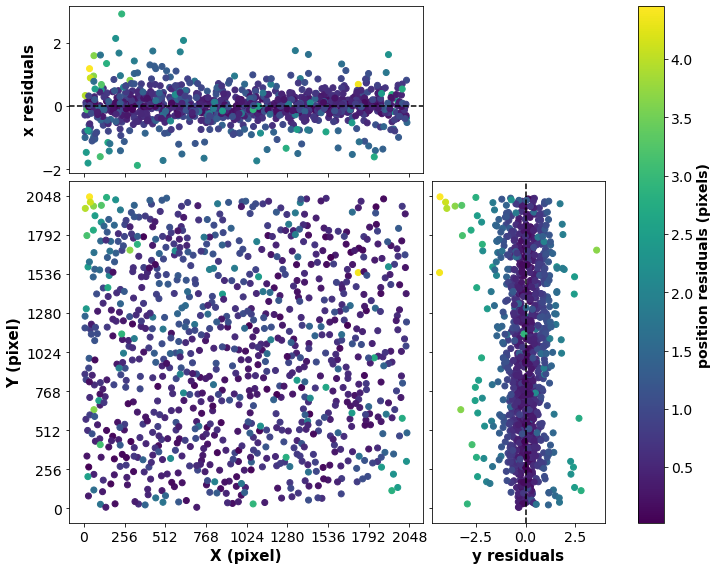

In [18]:
fig = plt.figure(figsize=(12,9.5))
ax1 = fig.add_subplot(3,3,(4,8))
ax2 = fig.add_subplot(3,3,(1,2))
ax3 = fig.add_subplot(3,3,(6,9))

plt.subplots_adjust(wspace=0.05, hspace=0.05)

sc = ax1.scatter(match_data[:,0], match_data[:,1], c=np.sqrt(x_res**2 + y_res**2))
ax1.xaxis.set_major_locator(plt.MultipleLocator(256))
ax1.yaxis.set_major_locator(plt.MultipleLocator(256))
ax1.set_xlabel('X (pixel)',fontsize=15, fontweight='bold')
ax1.set_ylabel('Y (pixel)',fontsize=15, fontweight='bold')

ax2.scatter(match_data[:,0], x_res, c=np.sqrt(x_res**2 + y_res**2))
ax2.xaxis.set_major_locator(plt.MultipleLocator(256))
ax2.set_xticklabels([])
ax2.set_ylabel('x residuals',fontsize=15, fontweight='bold')
ax2.axhline(0,ls='--',c='black')

ax3.scatter(y_res, match_data[:,1],c=np.sqrt(x_res**2 + y_res**2))
ax3.yaxis.set_major_locator(plt.MultipleLocator(256))
ax3.set_yticklabels([])
ax3.set_xlabel('y residuals',fontsize=15, fontweight='bold')
ax3.axvline(0,ls='--',c='black')

cbar = fig.colorbar(sc, ax=(ax1,ax2,ax3))
cbar.set_label('position residuals (pixels)',fontsize=14,fontweight='bold')

In [19]:
hdr1["CTYPE1"] += "-SIP"
hdr1["CTYPE2"] += "-SIP"

hdr1['CRPIX1'] -= x_coefs[0]
hdr1['CRPIX2'] -= y_coefs[0]

xy_orders = SIP_orders(x_pol, remove_order=removed_ord)
if "A_ORDER" in hdr1: hdr1["A_ORDER"] = x_pol
else: hdr1.insert("CDELT1",("A_ORDER", x_pol, "SIP x-polynomial order, detector to sky"))
for i in np.arange(1,len(x_coefs)):
    keyw = f"A_{xy_orders[0,i]}_{xy_orders[1,i]}"
    if keyw in hdr1: hdr1[keyw] = x_coefs[i]
    else: hdr1.insert("CDELT1", (keyw, x_coefs[i], "X SIP distortion coefficient"))
if "A_DMAX" in hdr1: hdr1["A_DMAX"] = 70
else: hdr1.insert("CDELT1",("A_DMAX", 70, "X maximum correction [pixel]"))

xy_orders = SIP_orders(y_pol, remove_order=removed_ord)
if "B_ORDER" in hdr1: hdr1["B_ORDER"] = y_pol
else: hdr1.insert("CDELT1", ("B_ORDER", y_pol, "SIP y-polynomial order, detector to sky"))
for i in np.arange(1,len(y_coefs)):
    keyw = f"B_{xy_orders[0,i]}_{xy_orders[1,i]}"
    if keyw in hdr1: hdr1[keyw] = y_coefs[i]
    else: hdr1.insert("CDELT1", (keyw, y_coefs[i], "Y SIP distortion coefficient"))
if "B_DMAX" in hdr1: hdr1["B_DMAX"] = 70
else: hdr1.insert("CDELT1",("B_DMAX", 70, "Y maximum correction [pixel]"))

with fits.open(imgname, mode='update') as hdu:
    hdu[0].header = hdr1

wcs = WCS(hdr1)
wcs

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 83.86854277543233  -69.23306059550623  
CRPIX : 1.071507025214036  2050.546207396547  
CD1_1 CD1_2  : 2.49987410874087e-05  2.50886517572596e-07  
CD2_1 CD2_2  : -2.508865175726e-07  2.49987410874087e-05  
NAXIS : 2048  2056